# 04 — Walking-Isochronen (5 / 10 / 15 Min)

**Ziel:** Für ausgewählte Beispielpunkte Walking-Isochronen berechnen, um die Methodik zu illustrieren — und das **Hex-Analyse-Gitter** über Zürich anlegen, in dem wir später den Score schreiben.

**Methode:** OSMnx-Walking-Graph → Kanten mit Gehzeit gewichten → `networkx.ego_graph` für jeden Mittelpunkt.

**Outputs:**
- `data/processed/zh_hex_grid.gpkg` — Analyse-Gitter (200 m Apothem)
- `reports/figures/isochrone_demo.png` — Isochronen-Karte für die Slides

## 1. Setup

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox
from shapely.geometry import Point

from zh15min import config, grid, isochron

## 2. Hex-Analyse-Gitter über die Stadt legen

In [2]:
# Boundary für Hex-Gitter: Union aller 34 offiziellen Stadt-Zürich-Quartiere
# (statt OSMnx-Stadtgrenze, die nur den inneren Kern abdeckt). Die Geometrien
# werden vor dem Union mit make_valid()/buffer(0) repariert, weil OSMnx-Importe
# manchmal kleine Self-Intersections oder Overlaps enthalten.
from shapely import make_valid

quart_for_boundary = gpd.read_file(config.EXTERNAL_DIR / 'quartiere.geojson').to_crs(config.EPSG_LV95)

# Defekte Geometrien reparieren (idempotent für valide Polygone)
clean_geoms = quart_for_boundary.geometry.apply(lambda g: make_valid(g) if g is not None else g)
city_union = clean_geoms.union_all()

boundary = gpd.GeoDataFrame(geometry=[city_union], crs=config.EPSG_LV95)
hex_grid = grid.hex_grid(boundary, apothem_m=config.HEX_RESOLUTION_M)
print(f'Hex-Gitter: {len(hex_grid):,} Zellen ({config.HEX_RESOLUTION_M} m Apothem)')
hex_grid.head(3)

Hex-Gitter: 744 Zellen (200 m Apothem)


,hex_id,centroid_x,centroid_y,geometry
0,0,2.676225e+06,1.247984e+06,"POLYGON ((2676455.635 1247984.106, 2676340.165..."
1,1,2.676225e+06,1.248384e+06,"POLYGON ((2676455.635 1248384.106, 2676340.165..."
2,2,2.676571e+06,1.247784e+06,"POLYGON ((2676802.045 1247784.106, 2676686.575..."


In [3]:
hex_grid.to_file(config.PROCESSED_DIR / 'zh_hex_grid.gpkg', layer='grid', driver='GPKG')

## 3. Walking-Graph laden & mit Gehzeit gewichten

In [4]:
graph_path = config.PROCESSED_DIR / 'zh_walk_graph.graphml'
G = ox.load_graphml(graph_path)
G = isochron.add_walk_time(G, speed_kmh=config.WALK_SPEED_KMH)
print(f'Graph: {len(G.nodes):,} Knoten, {len(G.edges):,} Kanten')

Graph: 61,780 Knoten, 164,668 Kanten


## 4. Demo: Isochronen für drei prominente Standorte

Gewählt sind drei Punkte mit unterschiedlichem Charakter — Innenstadt (HB), Wohnquartier (Wiedikon) und Entwicklungsgebiet (Leutschenbach).

In [5]:
demo_points_lv95 = {
    'Hauptbahnhof':   (2683160, 1248230),
    'Wiedikon':       (2681900, 1246150),
    'Leutschenbach':  (2685300, 1252700),
}

iso_records = []
for label, (x, y) in demo_points_lv95.items():
    for minutes in (5, 10, 15):
        poly = isochron.isochrone_polygon(G, (x, y), minutes=minutes)
        if poly is not None:
            iso_records.append({'point': label, 'minutes': minutes, 'geometry': poly})

iso_gdf = gpd.GeoDataFrame(iso_records, geometry='geometry', crs=config.EPSG_LV95)
iso_gdf.head(6)

,point,minutes,geometry
0,Hauptbahnhof,5,"POLYGON ((2683336.205 1247947.164, 2683275.939..."
1,Hauptbahnhof,10,"POLYGON ((2683320.761 1247586.048, 2683243.292..."
2,Hauptbahnhof,15,"POLYGON ((2683418.481 1247192.02, 2683269.109 ..."
3,Wiedikon,5,"POLYGON ((2681811.75 1245784.656, 2681733.383 ..."
4,Wiedikon,10,"POLYGON ((2681974.811 1245408.588, 2681728.287..."
5,Wiedikon,15,"POLYGON ((2681739.438 1245031.511, 2681306.629..."


Figur gespeichert: /Users/memissanir/Documents/Claude/Projects/Einsatz von Geodaten in Marketing/reports/figures/isochrone_demo.png


/var/folders/51/_lj17k3x0dsb01y8kfk20rgw0000gn/T/ipykernel_42734/3795095004.py:12: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title='Walking-Isochrone', loc='lower left')
/var/folders/51/_lj17k3x0dsb01y8kfk20rgw0000gn/T/ipykernel_42734/3795095004.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Walking-Isochrone', loc='lower left')


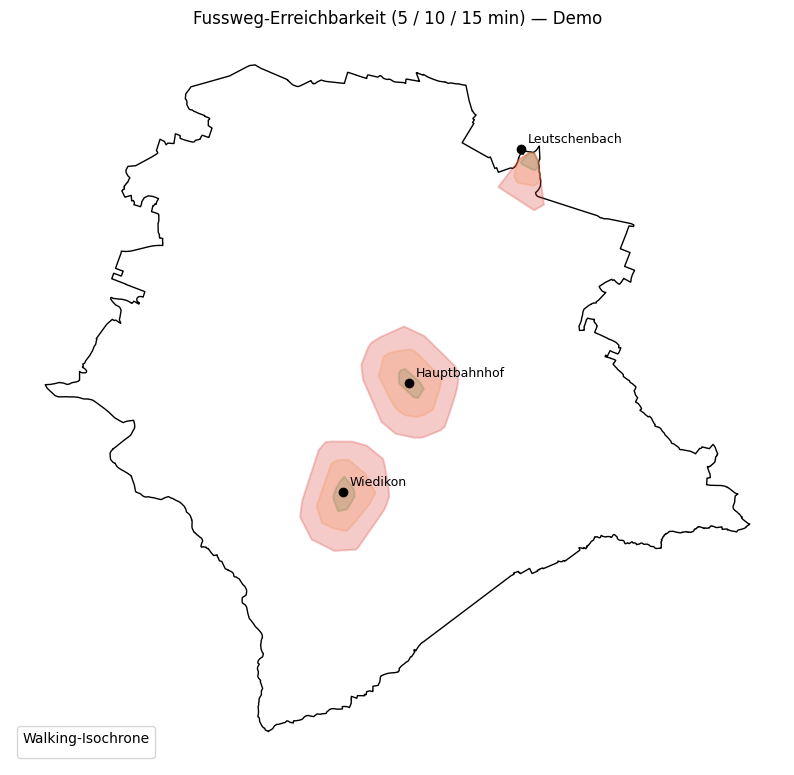

In [6]:
fig, ax = plt.subplots(figsize=(10, 10))
boundary.to_crs(config.EPSG_LV95).plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)

colors = {5: '#1a9850', 10: '#fdae61', 15: '#d73027'}
for minutes, sub in iso_gdf.groupby('minutes'):
    sub.plot(ax=ax, alpha=0.25, color=colors[minutes], edgecolor=colors[minutes], linewidth=1.4, label=f'{minutes} min')

for label, (x, y) in demo_points_lv95.items():
    ax.plot(x, y, 'ko', markersize=6)
    ax.annotate(label, (x, y), xytext=(5, 5), textcoords='offset points', fontsize=9)

ax.legend(title='Walking-Isochrone', loc='lower left')
ax.set_title('Fussweg-Erreichbarkeit (5 / 10 / 15 min) — Demo', fontsize=12)
ax.set_axis_off()
out = config.FIGURES_DIR / 'isochrone_demo.png'
fig.savefig(out, dpi=180, bbox_inches='tight')
print('Figur gespeichert:', out)

## 5. Zusammenfassung

- ✅ Hex-Gitter (200 m Apothem, 744 Zellen) über die ganze Stadt — Basis aller Score-Zellen.
- ✅ Demo-Isochronen für drei Standorte — illustriert die Methode in den Slides.
- ⚙️ Den Score selbst berechnen wir in Notebook 05 nicht über `ego_graph` für jede einzelne Zelle (zu langsam), sondern mit einer **Luftlinien-Approximation auf KDTree**, die für 744 Zellen × 8 092 POIs in Sekunden läuft. Die Isochronen dienen als Validierung und Visualisierung der Methode.
- 🛤️ Für die **topografische Variante** (Notebook 06b) wird stattdessen pro POI ein `single_source_dijkstra` mit Cutoff = 15 min auf dem Tobler-gewichteten Graph laufen — POI-zentriert ist effizient genug (~33 s) und fängt Steigungs-Asymmetrie korrekt ein.